In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/filename_format.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/filename_differences.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/168_1b1_Al_sc_Meditron.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/162_1b2_Ar_mc_AKGC417L.wav
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/172_1b4_Ar_mc_AKGC417L.txt
/kaggle/input/datase

In [2]:
import os

base_path = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/kaggle/input/datasets/vbookshelf/respiratory-sound-database


In [3]:


base_path = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database"

print(os.listdir(base_path))

['demographic_info.txt', 'Respiratory_Sound_Database', 'respiratory_sound_database']


In [4]:
path1 = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database"

import os
print(os.listdir(path1))

['Respiratory_Sound_Database']


In [5]:
path2 = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database"

import os
print(os.listdir(path2))

['patient_diagnosis.csv', 'filename_format.txt', 'audio_and_txt_files', 'filename_differences.txt']


In [6]:
audio_path = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

import os

files = os.listdir(audio_path)

print("Total files:", len(files))
print("\nFirst 10 files:")
print(files[:10])

Total files: 1840

First 10 files:
['168_1b1_Al_sc_Meditron.txt', '162_1b2_Ar_mc_AKGC417L.wav', '172_1b4_Ar_mc_AKGC417L.txt', '193_1b2_Pl_mc_AKGC417L.wav', '138_2p2_Ll_mc_AKGC417L.wav', '207_2b2_Ar_mc_AKGC417L.wav', '130_3p2_Pr_mc_AKGC417L.txt', '177_2b4_Pl_mc_AKGC417L.txt', '176_2b3_Pr_mc_AKGC417L.wav', '130_2p5_Pl_mc_AKGC417L.txt']


**Separate .wav and .txt Files**

In [7]:
wav_files = [f for f in files if f.endswith(".wav")]
txt_files = [f for f in files if f.endswith(".txt")]

print("Total wav files:", len(wav_files))
print("Total txt files:", len(txt_files))

print("\nFirst 5 wav files:")
print(wav_files[:5])

print("\nFirst 5 txt files:")
print(txt_files[:5])

Total wav files: 920
Total txt files: 920

First 5 wav files:
['162_1b2_Ar_mc_AKGC417L.wav', '193_1b2_Pl_mc_AKGC417L.wav', '138_2p2_Ll_mc_AKGC417L.wav', '207_2b2_Ar_mc_AKGC417L.wav', '176_2b3_Pr_mc_AKGC417L.wav']

First 5 txt files:
['168_1b1_Al_sc_Meditron.txt', '172_1b4_Ar_mc_AKGC417L.txt', '130_3p2_Pr_mc_AKGC417L.txt', '177_2b4_Pl_mc_AKGC417L.txt', '130_2p5_Pl_mc_AKGC417L.txt']


**Load Patient Diagnosis**

In [8]:
import pandas as pd

diagnosis_path = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"

diagnosis_df = pd.read_csv(diagnosis_path, header=None)

print("Shape:", diagnosis_df.shape)
print("\nFirst 10 rows:\n")
print(diagnosis_df.head(10))

Shape: (126, 2)

First 10 rows:

     0        1
0  101     URTI
1  102  Healthy
2  103   Asthma
3  104     COPD
4  105     URTI
5  106     COPD
6  107     COPD
7  108     LRTI
8  109     COPD
9  110     COPD


Name the Columns Properly

In [9]:
diagnosis_df.columns = ["patient_id", "disease"]

print(diagnosis_df.head())

   patient_id  disease
0         101     URTI
1         102  Healthy
2         103   Asthma
3         104     COPD
4         105     URTI


Create a Patient → Disease Dictionary

In [10]:
patient_disease = dict(zip(diagnosis_df["patient_id"], diagnosis_df["disease"]))

print("Total patients in dictionary:", len(patient_disease))

# show first 5 mappings
for i, (k, v) in enumerate(patient_disease.items()):
    print(k, "→", v)
    if i == 4:
        break

Total patients in dictionary: 126
101 → URTI
102 → Healthy
103 → Asthma
104 → COPD
105 → URTI


Extract Patient ID From Audio Filename

In [11]:
# take one sample file
sample_file = wav_files[0]

print("Sample file:", sample_file)

# extract patient id
patient_id = int(sample_file.split("_")[0])

print("Extracted patient ID:", patient_id)

# find disease
print("Disease:", patient_disease[patient_id])

Sample file: 162_1b2_Ar_mc_AKGC417L.wav
Extracted patient ID: 162
Disease: COPD


Open One Annotation File

In [12]:
# build txt filename from wav filename
txt_file = sample_file.replace(".wav", ".txt")

txt_path = os.path.join(audio_path, txt_file)

print("Annotation file:", txt_file)

# read annotation
annotation_df = pd.read_csv(txt_path, sep="\t", header=None)

print("\nFirst few rows:\n")
print(annotation_df.head())

Annotation file: 162_1b2_Ar_mc_AKGC417L.txt

First few rows:

        0       1  2  3
0   0.092   3.481  0  0
1   3.481  10.793  1  1
2  10.793  18.623  0  0


Load the Audio File

In [13]:
import librosa

wav_path = os.path.join(audio_path, sample_file)

audio, sr = librosa.load(wav_path, sr=None)

print("Sample rate:", sr)
print("Audio length (samples):", len(audio))
print("Audio duration (seconds):", len(audio)/sr)

Sample rate: 44100
Audio length (samples): 882000
Audio duration (seconds): 20.0


Convert Annotation Times to Sample Indices

In [14]:
# first breathing cycle
start_time = annotation_df.iloc[0,0]
end_time = annotation_df.iloc[0,1]

print("Start time:", start_time)
print("End time:", end_time)

# convert to sample index
start_sample = int(start_time * sr)
end_sample = int(end_time * sr)

print("\nStart sample:", start_sample)
print("End sample:", end_sample)

Start time: 0.092
End time: 3.481

Start sample: 4057
End sample: 153512


Extract the First Breathing Cycle

Extract the First Breathing Cycle

In [15]:
cycle_audio = audio[start_sample:end_sample]

print("Cycle length (samples):", len(cycle_audio))
print("Cycle duration (seconds):", len(cycle_audio)/sr)

Cycle length (samples): 149455
Cycle duration (seconds): 3.389002267573696


Convert the Cycle to Log-Mel Spectrogram

In [16]:
import numpy as np
import librosa

mel = librosa.feature.melspectrogram(
    y=cycle_audio,
    sr=sr,
    n_mels=128,
    fmax=sr/2
)

log_mel = librosa.power_to_db(mel, ref=np.max)

print("Mel spectrogram shape:", mel.shape)
print("Log-mel shape:", log_mel.shape)

Mel spectrogram shape: (128, 292)
Log-mel shape: (128, 292)


Resize Spectrogram

In [17]:
import cv2

spec_resized = cv2.resize(log_mel, (224, 224))

print("Resized spectrogram shape:", spec_resized.shape)

Resized spectrogram shape: (224, 224)


Extract All Cycles From One Recording

In [18]:
cycles = []

for i, row in annotation_df.iterrows():
    
    start_time = row[0]
    end_time = row[1]

    start_sample = int(start_time * sr)
    end_sample = int(end_time * sr)

    cycle_audio = audio[start_sample:end_sample]

    cycles.append(cycle_audio)

print("Total cycles extracted:", len(cycles))

Total cycles extracted: 3


Convert All Cycles → Spectrograms

In [19]:
spectrograms = []

for cycle in cycles:
    
    mel = librosa.feature.melspectrogram(
        y=cycle,
        sr=sr,
        n_mels=128,
        fmax=sr/2
    )
    
    log_mel = librosa.power_to_db(mel, ref=np.max)
    
    spec_resized = cv2.resize(log_mel, (224,224))
    
    spectrograms.append(spec_resized)

print("Total spectrograms:", len(spectrograms))
print("Shape of first spectrogram:", spectrograms[0].shape)

Total spectrograms: 3
Shape of first spectrogram: (224, 224)


Create Labels for Each Cycle

In [20]:
labels = []

disease_label = patient_disease[patient_id]

for _ in spectrograms:
    labels.append(disease_label)

print("Total labels:", len(labels))
print("Labels:", labels)

Total labels: 3
Labels: ['COPD', 'COPD', 'COPD']


In [21]:
X = []
y = []

print("Initialized dataset containers")

Initialized dataset containers


Process First 5 Audio Files

In [22]:
for wav_file in wav_files[:5]:

    # build full audio path
    wav_path = os.path.join(audio_path, wav_file)

    # load audio
    audio, sr = librosa.load(wav_path, sr=None)

    # find corresponding annotation file
    txt_file = wav_file.replace(".wav", ".txt")
    txt_path = os.path.join(audio_path, txt_file)

    annotation_df = pd.read_csv(txt_path, sep="\t", header=None)

    # extract patient id
    patient_id = int(wav_file.split("_")[0])

    # get disease label
    disease_label = patient_disease[patient_id]

    # process each breathing cycle
    for _, row in annotation_df.iterrows():

        start_time = row[0]
        end_time = row[1]

        start_sample = int(start_time * sr)
        end_sample = int(end_time * sr)

        cycle_audio = audio[start_sample:end_sample]

        mel = librosa.feature.melspectrogram(
            y=cycle_audio,
            sr=sr,
            n_mels=128,
            fmax=sr/2
        )

        log_mel = librosa.power_to_db(mel, ref=np.max)

        spec_resized = cv2.resize(log_mel, (224,224))

        X.append(spec_resized)
        y.append(disease_label)

print("Spectrogram samples:", len(X))
print("Label samples:", len(y))

Spectrogram samples: 35
Label samples: 35


Convert Labels to Numbers

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original labels:", y[:10])
print("Encoded labels:", y_encoded[:10])

Original labels: ['COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD']
Encoded labels: [0 0 0 0 0 0 0 0 0 0]


In [24]:
for disease, index in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(disease, "→", index)

COPD → 0


In [25]:
X = np.array(X)
y_encoded = np.array(y_encoded)

print("X shape:", X.shape)
print("y shape:", y_encoded.shape)

X shape: (35, 224, 224)
y shape: (35,)


In [26]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (35, 224, 224, 1)


Reset Dataset Containers

Process Entire Dataset

In [27]:
X = []
y = []

print("Dataset reset complete")

Dataset reset complete


In [28]:
from tqdm import tqdm

for wav_file in tqdm(wav_files):

    wav_path = os.path.join(audio_path, wav_file)

    # load audio
    audio, sr = librosa.load(wav_path, sr=None)

    # corresponding annotation file
    txt_file = wav_file.replace(".wav", ".txt")
    txt_path = os.path.join(audio_path, txt_file)

    annotation_df = pd.read_csv(txt_path, sep="\t", header=None)

    # extract patient id
    patient_id = int(wav_file.split("_")[0])

    # get disease label
    disease_label = patient_disease[patient_id]

    for _, row in annotation_df.iterrows():

        start_time = row[0]
        end_time = row[1]

        start_sample = int(start_time * sr)
        end_sample = int(end_time * sr)

        cycle_audio = audio[start_sample:end_sample]

        mel = librosa.feature.melspectrogram(
            y=cycle_audio,
            sr=sr,
            n_mels=128,
            fmax=sr/2
        )

        log_mel = librosa.power_to_db(mel, ref=np.max)

        spec_resized = cv2.resize(log_mel, (224,224))

        X.append(spec_resized)
        y.append(disease_label)

print("Total spectrogram samples:", len(X))
print("Total labels:", len(y))

 28%|██▊       | 262/920 [00:33<01:17,  8.45it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1848
  warnings.warn(
100%|██████████| 920/920 [01:58<00:00,  7.78it/s]

Total spectrogram samples: 6898
Total labels: 6898


In [29]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6898, 224, 224)
y shape: (6898,)


In [30]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (6898, 224, 224, 1)


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded labels example:", y_encoded[:10])
print("Total disease classes:", len(label_encoder.classes_))

print("\nDisease mapping:")
for disease, index in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(disease, "→", index)

Encoded labels example: [3 3 3 3 3 3 3 3 3 3]
Total disease classes: 8

Disease mapping:
Asthma → 0
Bronchiectasis → 1
Bronchiolitis → 2
COPD → 3
Healthy → 4
LRTI → 5
Pneumonia → 6
URTI → 7


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train dataset shape:", X_train.shape)
print("Test dataset shape:", X_test.shape)

Train dataset shape: (5518, 224, 224, 1)
Test dataset shape: (1380, 224, 224, 1)


In [33]:


X_train = (X_train - X_train.mean()) / (X_train.std() + 1e-8)
X_test = (X_test - X_test.mean()) / (X_test.std() + 1e-8)

print("Normalization done")

Normalization done


In [34]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(137.95), 1: np.float64(8.310240963855422), 2: np.float64(5.388671875), 3: np.float64(0.15007615317667536), 4: np.float64(2.673449612403101), 5: np.float64(26.528846153846153), 6: np.float64(3.025219298245614), 7: np.float64(3.5554123711340204)}


In [35]:
X_train_resnet = np.repeat(X_train, 3, axis=-1)
X_test_resnet = np.repeat(X_test, 3, axis=-1)

print("ResNet input shape:", X_train_resnet.shape)

ResNet input shape: (5518, 224, 224, 3)


In [36]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import Input

input_tensor = Input(shape=(224,224,3))

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=input_tensor
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(8, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

2026-04-08 22:35:46.441248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775687746.625525      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775687746.679096      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775687747.141190      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775687747.141228      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775687747.141231      24 computation_placer.cc:177] computation placer alr

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 24,061,192 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [37]:
from tensorflow.keras.optimizers import AdamW

optimizer = AdamW(
    learning_rate=1e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled with AdamW")

Model compiled with AdamW


In [38]:
history = model.fit(
    X_train_resnet,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_resnet, y_test),
    class_weight=class_weights
)

Epoch 1/20


I0000 00:00:1775687814.525180      77 service.cc:152] XLA service 0x7e1794015b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775687814.525221      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775687820.623627      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/173 ━━━━━━━━━━━━━━━━━━━━ 2:59:47 63s/step - accuracy: 0.0312 - loss: 2.0341

I0000 00:00:1775687843.897966      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


173/173 ━━━━━━━━━━━━━━━━━━━━ 125s 364ms/step - accuracy: 0.4215 - loss: 2.0457 - val_accuracy: 0.0181 - val_loss: 2.6825
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.7663 - loss: 0.7148 - val_accuracy: 0.0420 - val_loss: 2.2915
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.7657 - loss: 0.9236 - val_accuracy: 0.4949 - val_loss: 1.7142
Epoch 4/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.8583 - loss: 0.4270 - val_accuracy: 0.7420 - val_loss: 1.0564
Epoch 5/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.9085 - loss: 0.1846 - val_accuracy: 0.7580 - val_loss: 0.7305
Epoch 6/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.9066 - loss: 0.3268 - val_accuracy: 0.8326 - val_loss: 0.5321
Epoch 7/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.9403 - loss: 0.1122 - val_accuracy: 0.7138 - val_loss: 0.9504
Epoch 8/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.9386 - loss: 0.1705 - va

In [39]:
test_loss, test_acc = model.evaluate(X_test_resnet, y_test)

print("Test accuracy:", test_acc)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9070 - loss: 0.3043
Test accuracy: 0.9007246494293213


44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step


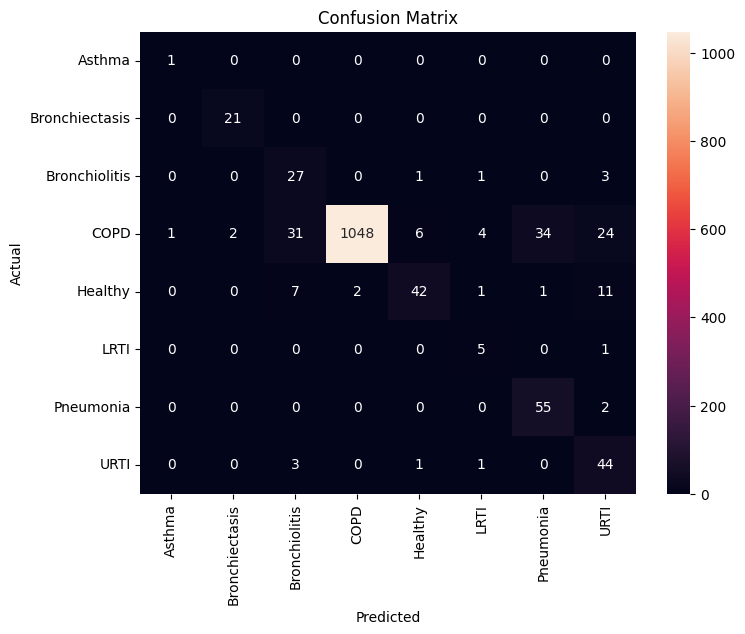

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_resnet)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()